In [1]:
# ===============================================
# Code Block 1 — Imports, Paths, Load Resource Dataset
# ===============================================

import os
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

IN_DIR  = "../data/processed"
OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

RES_FILE = os.path.join(IN_DIR, "resource_features_with_outliers.csv")
OUT_FILE = os.path.join(OUT_DIR, "resource_scores.csv")

if not os.path.exists(RES_FILE):
    raise FileNotFoundError(f"Missing file: {RES_FILE}")

res_df = pd.read_csv(RES_FILE)

print("Loaded resource dataset:", res_df.shape)
display(res_df.head())


Loaded resource dataset: (64, 13)


,resource,n_events,n_unique_cases,n_distinct_activities,handover_in,handover_out,avg_wait_before_event_seconds,avg_inter_event_seconds,avg_wait_before_event_hours,avg_inter_event_hours,avg_events_per_case,municipality,res_outlier
0,10716070,96,2,54,7.0,7.0,425633.684211,550325.274725,118.231579,152.868132,48.000000,BPIC15_1,True
1,1550894,12875,169,217,900.0,900.0,124427.269143,188601.153028,34.563130,52.389209,76.183432,BPIC15_4,True
2,1946514,180,4,63,0.0,0.0,80938.909091,77910.079309,22.483030,21.641689,45.000000,BPIC15_3,False
3,2013365,12905,184,210,793.0,793.0,89306.013834,128354.362852,24.807226,35.653990,70.135870,BPIC15_3,True
4,2670601,1363,45,146,61.0,61.0,161186.050038,174905.738252,44.773903,48.584927,30.288889,BPIC15_1,False


In [2]:
# ===============================================
# Code Block 2 — Select Resource Metrics
# ===============================================

resource_metrics = [
    "n_events",
    "n_unique_cases",
    "n_distinct_activities",
    "avg_wait_before_event_hours",
    "avg_inter_event_hours",
    "avg_events_per_case",
    "handover_in",
    "handover_out"
]

res_numeric = res_df[resource_metrics].copy()

# Clean infinities & NaNs
res_numeric = res_numeric.replace([np.inf, -np.inf], np.nan)
res_numeric = res_numeric.fillna(res_numeric.median())

print("Numeric resource metrics (cleaned):")
display(res_numeric.head())


Numeric resource metrics (cleaned):


,n_events,n_unique_cases,n_distinct_activities,avg_wait_before_event_hours,avg_inter_event_hours,avg_events_per_case,handover_in,handover_out
0,96,2,54,118.231579,152.868132,48.000000,7.0,7.0
1,12875,169,217,34.563130,52.389209,76.183432,900.0,900.0
2,180,4,63,22.483030,21.641689,45.000000,0.0,0.0
3,12905,184,210,24.807226,35.653990,70.135870,793.0,793.0
4,1363,45,146,44.773903,48.584927,30.288889,61.0,61.0


In [3]:
# ===============================================
# Code Block 3 — Transform Skewed Metrics
# ===============================================

# Workload metrics often skewed → apply log1p where appropriate
res_numeric["n_events"] = np.log1p(res_numeric["n_events"])
res_numeric["n_unique_cases"] = np.log1p(res_numeric["n_unique_cases"])

# avg_events_per_case also skewed
res_numeric["avg_events_per_case"] = np.log1p(res_numeric["avg_events_per_case"])

print("Applied log-transform to skewed metrics.")
display(res_numeric.head())


Applied log-transform to skewed metrics.


,n_events,n_unique_cases,n_distinct_activities,avg_wait_before_event_hours,avg_inter_event_hours,avg_events_per_case,handover_in,handover_out
0,4.574711,1.098612,54,118.231579,152.868132,3.891820,7.0,7.0
1,9.463120,5.135798,217,34.563130,52.389209,4.346185,900.0,900.0
2,5.198497,1.609438,63,22.483030,21.641689,3.828641,0.0,0.0
3,9.465448,5.220356,210,24.807226,35.653990,4.264592,793.0,793.0
4,7.218177,3.828641,146,44.773903,48.584927,3.443263,61.0,61.0


In [4]:
# ===============================================
# Code Block 4 — Normalize Metrics (0–1)
# ===============================================

def normalize_series(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

def normalize_series_invert(s):
    s_norm = normalize_series(s)
    return 1 - s_norm   # lower = better

res_norm = pd.DataFrame(index=res_df.index)

# Invert where lower is better
res_norm["wait"] = normalize_series_invert(res_numeric["avg_wait_before_event_hours"])
res_norm["inter"] = normalize_series_invert(res_numeric["avg_inter_event_hours"])
res_norm["handover_out"] = normalize_series_invert(res_numeric["handover_out"])

# Treat n_events, n_unique_cases, n_distinct_activities as stabilizing workload metrics
res_norm["workload"]  = normalize_series_invert(res_numeric["n_events"])
res_norm["case_load"] = normalize_series_invert(res_numeric["n_unique_cases"])
res_norm["activity_div"] = normalize_series(res_numeric["n_distinct_activities"])

# avg_events_per_case → high could mean overload → invert
res_norm["avg_events"] = normalize_series_invert(res_numeric["avg_events_per_case"])

print("Normalized resource metrics:")
display(res_norm.head())


Normalized resource metrics:


,wait,inter,handover_out,workload,case_load,activity_div,avg_events
0,0.153200,0.782701,0.994717,0.687851,0.920960,0.186047,0.494001
1,0.752698,0.927095,0.320755,0.076328,0.133969,0.817829,0.367146
2,0.839254,0.971281,1.000000,0.609817,0.821382,0.220930,0.511640
3,0.822601,0.951145,0.401509,0.076037,0.117486,0.790698,0.389926
4,0.679536,0.932562,0.953962,0.357162,0.388780,0.542636,0.619234


In [5]:
# ===============================================
# Code Block 5 — Clean NaNs + Drop Constant Columns Before PCA
# ===============================================

res_norm = res_norm.replace([np.inf, -np.inf], np.nan)
res_norm = res_norm.fillna(res_norm.median())

constant_cols = [c for c in res_norm.columns if res_norm[c].std() == 0]

if constant_cols:
    print("Dropping constant columns:", constant_cols)
    res_norm = res_norm.drop(columns=constant_cols)

if res_norm.isna().sum().sum() > 0:
    print("WARNING: Remaining NaNs found. Filling with 0.")
    res_norm = res_norm.fillna(0)

print("\nres_norm ready for PCA. Shape:", res_norm.shape)
display(res_norm.head())



res_norm ready for PCA. Shape: (64, 7)


,wait,inter,handover_out,workload,case_load,activity_div,avg_events
0,0.153200,0.782701,0.994717,0.687851,0.920960,0.186047,0.494001
1,0.752698,0.927095,0.320755,0.076328,0.133969,0.817829,0.367146
2,0.839254,0.971281,1.000000,0.609817,0.821382,0.220930,0.511640
3,0.822601,0.951145,0.401509,0.076037,0.117486,0.790698,0.389926
4,0.679536,0.932562,0.953962,0.357162,0.388780,0.542636,0.619234


In [6]:
# ===============================================
# Code Block 6 — PCA Weighting
# ===============================================

scaler = StandardScaler()
X = scaler.fit_transform(res_norm)

pca = PCA(n_components=1)
pca.fit(X)

loadings = np.abs(pca.components_[0])
w_pca = loadings / loadings.sum()

print("PCA Weights:")
for col, w in zip(res_norm.columns, w_pca):
    print(f"{col}: {w:.3f}")


PCA Weights:
wait: 0.012
inter: 0.061
handover_out: 0.179
workload: 0.204
case_load: 0.196
activity_div: 0.199
avg_events: 0.149


In [7]:
# ===============================================
# Code Block 7 — Entropy Weighting
# ===============================================

mm = MinMaxScaler()
vals = mm.fit_transform(res_norm)

P = vals / (vals.sum(axis=0) + 1e-12)
E = np.array([entropy(P[:,i]) for i in range(P.shape[1])])
d = 1 - E / np.log(len(P))

w_entropy = d / d.sum()

print("Entropy Weights:")
for col, w in zip(res_norm.columns, w_entropy):
    print(f"{col}: {w:.3f}")


Entropy Weights:
wait: 0.071
inter: 0.020
handover_out: 0.078
workload: 0.245
case_load: 0.169
activity_div: 0.297
avg_events: 0.119


In [8]:
# ===============================================
# Code Block 8 — Final Resource Weights (Average)
# ===============================================

w_final = (w_pca + w_entropy) / 2
w_final = w_final / w_final.sum()

resource_weights = dict(zip(res_norm.columns, w_final))

print("Final Resource Weights:")
for k,v in resource_weights.items():
    print(f"{k}: {v:.3f}")


Final Resource Weights:
wait: 0.041
inter: 0.040
handover_out: 0.129
workload: 0.225
case_load: 0.183
activity_div: 0.248
avg_events: 0.134


In [9]:
# ===============================================
# Code Block 9 — Compute Resource Score
# ===============================================

res_raw_score = np.zeros(len(res_norm))

for col in res_norm.columns:
    res_raw_score += res_norm[col] * resource_weights[col]

res_score = (res_raw_score - res_raw_score.min()) / (res_raw_score.max() - res_raw_score.min())

res_df["resource_score"] = res_score.round(3)

print("Resource Score Sample:")
display(res_df[["resource", "resource_score"]].head(10))


Resource Score Sample:


,resource,resource_score
0,10716070,0.641
1,1550894,0.166
2,1946514,0.670
3,2013365,0.184
4,2670601,0.536
5,2894257,0.972
6,3069865,0.413
7,3069866,0.249
8,3122446,0.603
9,3148844,0.714


In [10]:
# ===============================================
# Code Block 10 — Save resource_scores.csv
# ===============================================

out_cols = ["resource", "resource_score", "res_outlier"]
out_cols = [c for c in out_cols if c in res_df.columns]

resource_out = res_df[out_cols].round(3)

resource_out.to_csv(OUT_FILE, index=False)

print(f"Saved resource_scores.csv to:\n{OUT_FILE}")


Saved resource_scores.csv to:
../data/processed\resource_scores.csv


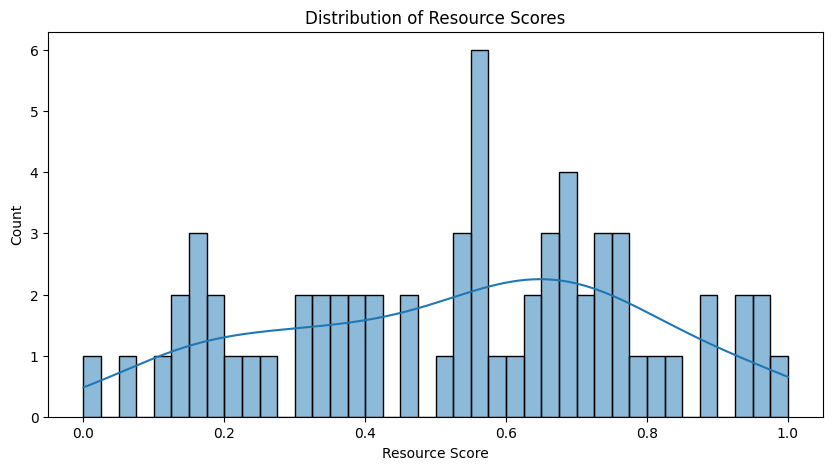

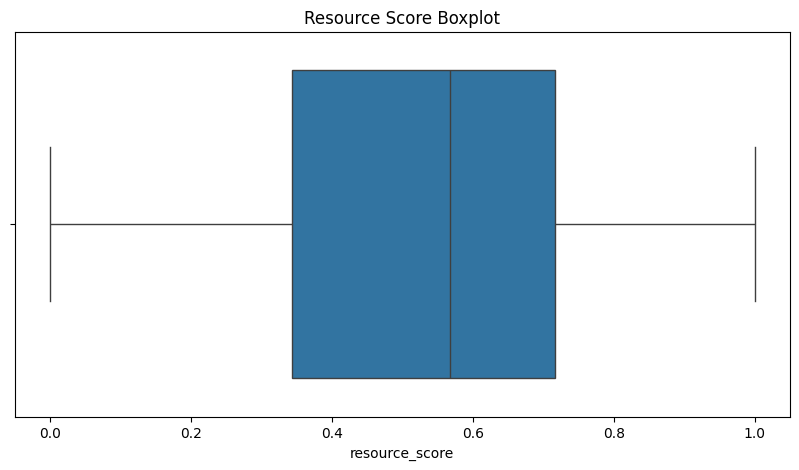

Top 10 Resources:


,resource,n_events,n_unique_cases,n_distinct_activities,handover_in,handover_out,avg_wait_before_event_seconds,avg_inter_event_seconds,avg_wait_before_event_hours,avg_inter_event_hours,avg_events_per_case,municipality,res_outlier,resource_score
42,560699,7,1,6,3.0,3.0,245.571429,6.490567e+04,0.068214,18.029352,7.0,BPIC15_3,False,1.000
5,2894257,9,1,8,2.0,2.0,889.111111,5.966500e+03,0.246975,1.657361,9.0,BPIC15_3,False,0.972
37,560665,9,1,9,2.0,2.0,3765.666667,3.066364e+05,1.046019,85.176771,9.0,BPIC15_3,False,0.962
55,560890,11,1,10,0.0,0.0,8640.000000,8.640000e+03,2.400000,2.400000,11.0,BPIC15_1,False,0.947
47,560781,12,1,12,0.0,0.0,18582.727273,1.858273e+04,5.161869,5.161869,12.0,BPIC15_4,False,0.936
28,560532,19,1,19,8.0,8.0,175.368421,2.609915e+05,0.048713,72.497639,19.0,BPIC15_2,False,0.877
54,560884,9,1,9,5.0,5.0,276.222222,2.511080e+06,0.076728,697.522361,9.0,BPIC15_1,True,0.877
63,Unknown,19,1,18,0.0,0.0,165727.555556,1.657276e+05,46.035432,46.035432,19.0,BPIC15_1,False,0.848
39,560690,23,2,13,0.0,0.0,246857.142857,2.412000e+05,68.571429,67.000000,11.5,BPIC15_3,False,0.812
34,560602,50,1,47,0.0,0.0,81110.204082,8.111020e+04,22.530612,22.530612,50.0,BPIC15_5,False,0.787


Bottom 10 Resources:


,resource,n_events,n_unique_cases,n_distinct_activities,handover_in,handover_out,avg_wait_before_event_seconds,avg_inter_event_seconds,avg_wait_before_event_hours,avg_inter_event_hours,avg_events_per_case,municipality,res_outlier,resource_score
35,560604,23377,251,223,1325.0,1325.0,77782.485580,151682.032041,21.606246,42.133898,93.135458,BPIC15_5,True,0.000
51,560852,21252,320,236,1175.0,1176.0,151232.732371,220080.637729,42.009092,61.133510,66.412500,BPIC15_4,True,0.063
16,4901428,23700,337,264,1171.0,1171.0,120209.574816,194903.978448,33.391549,54.139994,70.326409,BPIC15_1,True,0.120
22,560458,13311,47,226,1133.0,1133.0,75836.730494,343498.115666,21.065758,95.416143,283.212766,BPIC15_2,True,0.125
21,560454,18701,259,238,1063.0,1062.0,94037.938625,134617.124287,26.121650,37.393646,72.204633,BPIC15_3,True,0.128
33,560600,16388,182,232,915.0,915.0,121594.500833,231394.885163,33.776250,64.276357,90.043956,BPIC15_5,True,0.159
1,1550894,12875,169,217,900.0,900.0,124427.269143,188601.153028,34.563130,52.389209,76.183432,BPIC15_4,True,0.166
48,560812,6148,46,126,499.0,499.0,67185.106997,236568.316347,18.662530,65.713421,133.652174,BPIC15_4,True,0.169
3,2013365,12905,184,210,793.0,793.0,89306.013834,128354.362852,24.807226,35.653990,70.135870,BPIC15_3,True,0.184
41,560696,14069,209,224,903.0,904.0,45962.690354,96616.611787,12.767414,26.837948,67.315789,BPIC15_3,True,0.188


In [11]:
# ===============================================
# Code Block 11 — Diagnostics & Plots
# ===============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(res_df["resource_score"], kde=True, bins=40)
plt.title("Distribution of Resource Scores")
plt.xlabel("Resource Score")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=res_df["resource_score"])
plt.title("Resource Score Boxplot")
plt.show()

print("Top 10 Resources:")
display(res_df.sort_values("resource_score", ascending=False).head(10))

print("Bottom 10 Resources:")
display(res_df.sort_values("resource_score").head(10))


In [ ]:
# Replace case_df with your case-level DataFrame name
# Ensure each column below exists in that DataFrame

case_metric_cols = [
    "case_cycle_time",          # case cycle time
    "active_processing_time",   # active processing time
    "waiting_time",             # waiting / idle time
    "structural_complexity",    # structural complexity per case
    "total_case_cost",          # total cost per case
    "event_count",              # number of events per case
    "case_hybrid_score",        # hybrid performance score per case
    "case_outlier_score",       # or case_efficiency_index, etc.
]

case_metric_titles = [
    "Case Cycle Time",
    "Active Processing Time",
    "Waiting Time",
    "Structural Complexity",
    "Total Cost per Case",
    "Event Count per Case",
    "Case Hybrid Performance Score",
    "Case Outlier / Efficiency Score",
]

fig_case, axes_case = plot_metric_dashboard(
    df=case_df,
    metric_cols=case_metric_cols,
    titles=case_metric_titles,
    n_cols=4,  # 2x4 grid → 8 tiles
    suptitle="Case Performance Dashboard",
    x_axis_label="Case index (sorted by metric)",
)